# Business Understanding

## Latar Belakang

Perkembangan dunia kerja yang semakin dinamis menyebabkan kebutuhan kompetensi pada setiap posisi pekerjaan terus berubah. Banyak pencari kerja memiliki kesulitan dalam mengetahui apakah kompetensi yang mereka miliki sudah sesuai dengan kebutuhan industri dan target karier yang ingin dicapai.

Di sisi lain, informasi mengenai kompetensi yang dibutuhkan pada suatu pekerjaan umumnya tersebar di berbagai lowongan kerja sehingga sulit dianalisis secara manual. Akibatnya, pengguna sering tidak mengetahui tingkat kecocokan kompetensi (*skill match*) yang dimiliki terhadap pekerjaan yang diinginkan serta mengalami kesenjangan kompetensi (*skill gap*) yang dapat mengurangi peluang mereka untuk memperoleh pekerjaan tersebut.

Oleh karena itu, diperlukan suatu sistem yang dapat membantu pengguna mengidentifikasi tingkat kecocokan kompetensi dengan pekerjaan target, mengetahui kompetensi yang masih perlu dikembangkan, serta memperoleh rekomendasi pekerjaan yang sesuai dengan kompetensi yang dimiliki.

---

## Permasalahan

1. Pengguna tidak mengetahui tingkat kecocokan kompetensi (*skill match*) yang dimiliki terhadap target karier yang diinginkan.

2. Pengguna kesulitan mengidentifikasi kompetensi apa saja yang masih perlu dipelajari untuk memenuhi kebutuhan suatu pekerjaan (*skill gap*).

3. Pengguna kesulitan menemukan alternatif pekerjaan yang sesuai dengan kompetensi yang telah dimiliki saat ini.

---

## Tujuan

Analisis data lowongan pekerjaan dilakukan untuk:

* Mengidentifikasi kategori skill yang paling banyak dibutuhkan dalam lowongan pekerjaan.
* Mengidentifikasi posisi pekerjaan yang paling banyak tersedia dalam dataset.
* Menganalisis hubungan antara kategori skill dan posisi pekerjaan.
* Mengukur tingkat kecocokan kompetensi (*skill match*) dan kesenjangan kompetensi (*skill gap*) antara kompetensi pengguna dan kebutuhan pekerjaan target.
* Menyediakan dasar pengembangan sistem rekomendasi pekerjaan berbasis kompetensi.

---

## Solusi

Membangun sistem **SkillMatch** yang melakukan analisis kecocokan kompetensi (*skill match*) dan kesenjangan kompetensi (*skill gap*) antara kompetensi yang dimiliki pengguna dengan kompetensi yang dibutuhkan pada posisi pekerjaan target.

Sistem akan menghasilkan:

* Persentase kecocokan kompetensi (*Skill Match Score*).
* Daftar kompetensi yang telah dimiliki pengguna.
* Daftar kompetensi yang masih perlu dipelajari (*Skill Gap*).
* Rekomendasi pekerjaan alternatif yang sesuai dengan kompetensi pengguna.

---

## Manfaat

### Bagi Pengguna

* Mengetahui tingkat kecocokan kompetensi dengan pekerjaan yang ditargetkan.
* Memahami kompetensi yang perlu dipelajari untuk meningkatkan peluang kerja.
* Memperoleh rekomendasi pekerjaan yang sesuai dengan kompetensi yang dimiliki.
* Membantu menyusun rencana pengembangan kompetensi secara lebih terarah.

### Bagi Pengembang Sistem

* Menyediakan dasar pengembangan sistem rekomendasi karier berbasis data.
* Membantu proses pengambilan keputusan terkait pengembangan kompetensi pengguna.
* Menyediakan mekanisme analisis *skill match* dan *skill gap* yang dapat dimanfaatkan dalam pengembangan fitur karier berbasis data.


### **📑 Dokumentasi Teknis: Data Wrangling & Preprocessing SkillMatch**
Dokumen ini merinci siklus hidup data (data life cycle) dalam proyek SkillMatch, mulai dari pembersihan hingga persiapan data untuk model AI. Fokus utama adalah memastikan kualitas data tinggi untuk meminimalkan risiko kesalahan ekstraksi skill dan halusinasi model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re                                       
import csv                                      
from sklearn.model_selection import train_test_split                     
import warnings
warnings.filterwarnings('ignore')

# Setting style visualisasi
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Semua library utama berhasil diimport!')

Semua library utama berhasil diimport!


**Tahap 1: Inisialisasi & Penggabungan Data**

Tujuannya adalah menggabungkan dataset lowongan kerja (job_postings.csv) dengan dataset keterampilan (job_skills.csv) agar setiap baris data memiliki atribut yang lengkap.

In [ ]:


# Load dengan pengaturan tambahan
job_postings = pd.read_csv('job_postings.csv', on_bad_lines='skip', engine='python')
job_skills = pd.read_csv('job_skills.csv')

print(f"Jumlah baris job_postings: {len(job_postings)}")
print(f"Jumlah baris job_skills: {len(job_skills)}")

# Merging: Menyatukan skill ke dalam satu baris per job_id
# Karena satu job_id bisa punya banyak skill, kita group dulu
skills_grouped = job_skills.groupby('job_id')['skill_abr'].apply(lambda x: ', '.join(x)).reset_index()

# Gabungkan dengan tabel utama
df = pd.merge(job_postings, skills_grouped, on='job_id', how='left')

# Pilih kolom yang relevan saja untuk tahap awal
columns_to_keep = ['job_id', 'title', 'description', 'skill_abr', 'formatted_work_type', 'location', 'min_salary', 'max_salary']
df = df[columns_to_keep]

Jumlah baris job_postings: 15886
Jumlah baris job_skills: 27899


**Tahap 2: Data Cleaning & Preprocessing**

Tujuannya Menjamin data unik dan tidak ada 'lubang' pada fitur utama.

In [11]:
# 1. Hapus Duplikat (Berdasarkan Judul dan Deskripsi)
initial_count = len(df)
df = df.drop_duplicates(subset=['title', 'description'])
print(f"✅ Menghapus {initial_count - len(df)} data duplikat.")

# 2. Hapus data tanpa Skill atau Deskripsi (Wajib ada untuk AI)
df = df.dropna(subset=['skill_abr', 'description'])

# 3. Handling Gaji (Isi NaN dengan 0 untuk Dashboard)
df['min_salary'] = df['min_salary'].fillna(0)
df['max_salary'] = df['max_salary'].fillna(0)

# 4. Filter Outlier Gaji (Opsional: menghapus input gaji yang tidak masuk akal)
df = df[df['min_salary'] < 1000000]

print(f"✅ Data tersisa setelah pembersihan awal: {len(df)} baris.")

✅ Menghapus 1792 data duplikat.
✅ Data tersisa setelah pembersihan awal: 13466 baris.


**Tahap 3: Advanced Data Cleaning**

Tahap ini krusial untuk memperbaiki teks deskripsi agar siap diproses oleh model NLP tim AI. Kami menangani isu encoding dan mencegah kata-kata yang menempel akibat penghapusan tanda baca yang salah.

In [12]:
def advanced_clean_text(text):
    if not isinstance(text, str): return ""

    # Menghapus tag HTML
    text = re.sub(r'<.*?>', ' ', text)

    # Menangani error encoding (Mojibake)
    text = text.replace('â€™', "'").replace('â€¢', " ").replace('â€', " ")

    # Mencegah kata menempel: Ganti tanda baca dengan SPASI
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Normalisasi: lowercase dan hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).lower().strip()
    return text

# Menerapkan fungsi pada dataset
df['description_cleaned'] = df['description'].apply(advanced_clean_text)
df['title_cleaned'] = df['title'].apply(advanced_clean_text)

# Menghapus baris yang datanya tidak lengkap (null)
df_clean = df.dropna(subset=['skill_abr', 'description_cleaned']).copy()

**Tahap 4: Master Skill List & Transformasi Label**

Langkah mitigasi risiko AI Hallucination.

In [13]:
# 1. Ekstrak Master Skill List (Rule-based constraint)
all_skills = df['skill_abr'].str.split(',').explode().str.strip()
master_skills = pd.DataFrame(all_skills.unique(), columns=['Master_Skill_List']).sort_values('Master_Skill_List')

# 2. Ubah string skill menjadi List Python untuk training AI
df['target_skills_list'] = df['skill_abr'].apply(lambda x: [s.strip() for s in str(x).split(',') if s.strip()])

print(f"✅ Master Skill List dibuat ({len(master_skills)} skill unik).")

✅ Master Skill List dibuat (35 skill unik).


**Tahap 5: Train-Test Split & Ekspor Final**

Membagi data untuk tim AI dan dokumentasi.

In [14]:
# Membagi data (80% Train, 20% Test)
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

# Simpan ke CSV dengan quoting=csv.QUOTE_ALL agar koma dalam deskripsi aman
train_data.to_csv('skillmatch_train_data.csv', index=False, quoting=csv.QUOTE_ALL)
test_data.to_csv('skillmatch_test_data.csv', index=False, quoting=csv.QUOTE_ALL)
master_skills.to_csv('master_skill_list.csv', index=False)

print("🚀 PIPELINE SELESAI!")
print(f"📁 'skillmatch_train_data.csv' ({len(train_data)} baris) -> Untuk Yulia & Hamim")
print(f"📁 'skillmatch_test_data.csv' ({len(test_data)} baris) -> Simpan untuk Evaluasi")
print(f"📁 'master_skill_list.csv' -> Berikan ke Ghulam untuk Backend")

🚀 PIPELINE SELESAI!
📁 'skillmatch_train_data.csv' (10772 baris) -> Untuk Yulia & Hamim
📁 'skillmatch_test_data.csv' (2694 baris) -> Simpan untuk Evaluasi
📁 'master_skill_list.csv' -> Berikan ke Ghulam untuk Backend


---
## **Exploratory Data Analysis (EDA)**

## Data Dictionary

| Kolom | Tipe Data | Deskripsi |
|---------|---------|---------|
| job_id | Integer | ID unik lowongan |
| title | Object | Judul pekerjaan |
| title_cleaned | Object | Judul pekerjaan setelah preprocessing |
| description | Object | Deskripsi pekerjaan |
| skill_abr | Object | Kategori skill yang dibutuhkan |
| target_skills_list | List | Daftar skill dalam bentuk list |
| min_salary | Float | Gaji minimum |
| max_salary | Float | Gaji maksimum |
| num_skills | Integer | Jumlah skill pada lowongan |

In [56]:
## Load data bersih 

df_clean = pd.read_csv('../02_Data_Science_Internal/skillmatch_train_data.csv')
print(f" Berhasil memuat data bersih ! Jumlah data: {len(df_clean):,} baris.")

 Berhasil memuat data bersih ! Jumlah data: 10,772 baris.


Analisis dilakukan terhadap 10.772 data lowongan pekerjaan hasil proses data cleaning dan preprocessing.

In [57]:
df_clean.head()

,job_id,title,description,skill_abr,formatted_work_type,location,min_salary,max_salary,description_cleaned,title_cleaned,target_skills_list
0,3701368625,Senior IT Project Manager,Are you a seasoned IT professional looking to ...,"PRJM, IT",Contract,"St Louis, MO",94000.0,104000.0,are you a seasoned it professional looking to ...,senior it project manager,"['PRJM', 'IT']"
1,3701304516,Software Engineer,About This PositionThis is a W2 position that ...,"ENG, IT",Full-time,"New York, NY",0.0,0.0,about this positionthis is a w2 position that ...,software engineer,"['ENG', 'IT']"
2,3697384104,Electrician,Description\nTradesmen International is immedi...,"MGMT, MNFC",Full-time,"Hilton, NY",23.0,29.0,description tradesmen international is immedia...,electrician,"['MGMT', 'MNFC']"
3,3694109309,Aircraft Maintenance Supervisor,RESPONSIBILITIES SHALL INCLUDE BUT NOT LIMITED...,"ENG, IT",Full-time,"Andrews AFB, MD",0.0,0.0,responsibilities shall include but not limited...,aircraft maintenance supervisor,"['ENG', 'IT']"
4,3701314303,Housekeeping,Are you looking for an adventure of a lifetime...,"CUST, OTHR, BD",Full-time,"Nebraska, United States",0.0,0.0,are you looking for an adventure of a lifetime...,housekeeping,"['CUST', 'OTHR', 'BD']"


In [58]:
# ==============================================================================
# Mapping Kode Skill ke Nama Asli
# ==============================================================================

skill_mapping = {
    'ACCT': 'Accounting',
    'ADM': 'Administration',
    'ADVR': 'Advertising',
    'ANLS': 'Analysis',
    'ART': 'Art & Creative',
    'BD': 'Business Development',
    'CNSL': 'Consulting',
    'CUST': 'Customer Service',
    'DIST': 'Distribution',
    'DSGN': 'Design',
    'EDU': 'Education',
    'ENG': 'Engineering',
    'FIN': 'Finance',
    'GENB': 'General Business',
    'HCPR': 'Healthcare Provider',
    'HR': 'Human Resources',
    'IT': 'Information Technology',
    'LGL': 'Legal',
    'MGMT': 'Management',
    'MNFC': 'Manufacturing',
    'MRKT': 'Marketing',
    'OTHR': 'Other',
    'PR': 'Public Relations',
    'PRCH': 'Purchasing',
    'PRDM': 'Product Management',
    'PRJM': 'Project Management',
    'PROD': 'Production',
    'QA': 'Quality Assurance',
    'RSCH': 'Research',
    'SALE': 'Sales',
    'SCI': 'Science',
    'STRA': 'Strategy',
    'SUPL': 'Supply Chain',
    'TRNG': 'Training',
    'WRT': 'Writing'
}

In [59]:
# ==============================================================================
# Feature Engineering
# ==============================================================================

# 1. Menghitung jumlah skill pada setiap lowongan
df_clean['num_skills'] = (
    df_clean['skill_abr']
    .str.split(',')
    .apply(len)
)


# Melihat hasil
df_clean[['skill_abr', 'num_skills']].head()

,skill_abr,num_skills
0,"PRJM, IT",2
1,"ENG, IT",2
2,"MGMT, MNFC",2
3,"ENG, IT",2
4,"CUST, OTHR, BD",3


Fitur `num_skills` digunakan untuk mengetahui jumlah keterampilan yang dibutuhkan pada setiap lowongan pekerjaan.

Sedangkan fitur `salary_range` digunakan untuk melihat selisih antara gaji minimum dan maksimum sebagai indikator fleksibilitas kompensasi perusahaan.


In [60]:
df_clean.head()

,job_id,title,description,skill_abr,formatted_work_type,location,min_salary,max_salary,description_cleaned,title_cleaned,target_skills_list,num_skills
0,3701368625,Senior IT Project Manager,Are you a seasoned IT professional looking to ...,"PRJM, IT",Contract,"St Louis, MO",94000.0,104000.0,are you a seasoned it professional looking to ...,senior it project manager,"['PRJM', 'IT']",2
1,3701304516,Software Engineer,About This PositionThis is a W2 position that ...,"ENG, IT",Full-time,"New York, NY",0.0,0.0,about this positionthis is a w2 position that ...,software engineer,"['ENG', 'IT']",2
2,3697384104,Electrician,Description\nTradesmen International is immedi...,"MGMT, MNFC",Full-time,"Hilton, NY",23.0,29.0,description tradesmen international is immedia...,electrician,"['MGMT', 'MNFC']",2
3,3694109309,Aircraft Maintenance Supervisor,RESPONSIBILITIES SHALL INCLUDE BUT NOT LIMITED...,"ENG, IT",Full-time,"Andrews AFB, MD",0.0,0.0,responsibilities shall include but not limited...,aircraft maintenance supervisor,"['ENG', 'IT']",2
4,3701314303,Housekeeping,Are you looking for an adventure of a lifetime...,"CUST, OTHR, BD",Full-time,"Nebraska, United States",0.0,0.0,are you looking for an adventure of a lifetime...,housekeeping,"['CUST', 'OTHR', 'BD']",3


### Pertanyaan Bisnis

1. Kategori skill apa yang paling banyak dibutuhkan dalam lowongan pekerjaan?

2. Posisi pekerjaan apa yang paling sering muncul dalam dataset?

3. Bagaimana hubungan antara kategori skill dan posisi pekerjaan yang tersedia?

4. Berapa banyak kategori skill yang umumnya dibutuhkan dalam satu lowongan pekerjaan?


In [61]:
# ==============================================================================
# EDA 1 — Kategori Skill yang Paling Banyak Dibutuhkan
# ==============================================================================

skills_series = (
    df_clean['skill_abr']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

skill_counts = (
    skills_series
    .value_counts()
    .reset_index()
)

skill_counts.columns = ['Skill', 'Frequency']

# Mengubah kode skill menjadi nama asli
skill_counts['Skill'] = skill_counts['Skill'].map(skill_mapping)

# Tampilkan top 10
skill_counts.head(10)

,Skill,Frequency
0,Information Technology,2673
1,Management,1775
2,Sales,1767
3,Manufacturing,1558
4,Engineering,1294
5,Other,1081
6,Business Development,1073
7,Healthcare Provider,1002
8,Finance,891
9,Accounting,597


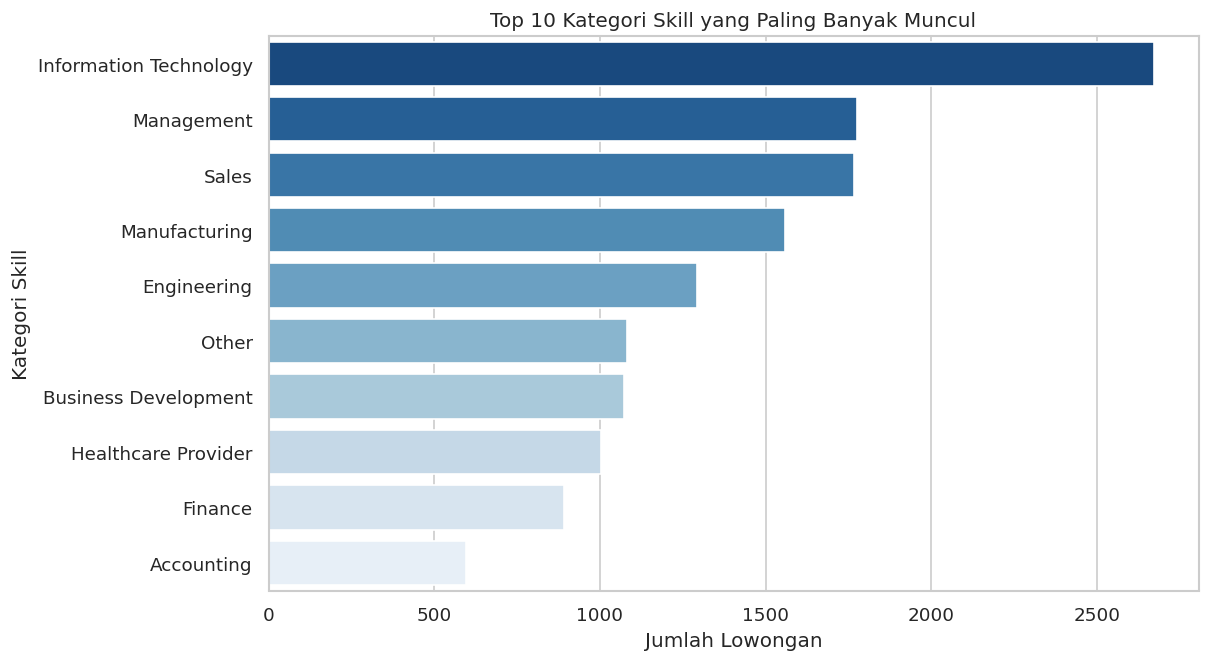

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=skill_counts.head(10),
    x='Frequency',
    y='Skill',
    palette='Blues_r'
)

plt.title('Top 10 Kategori Skill yang Paling Banyak Muncul')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Kategori Skill')

plt.show()

### Jawaban Pertanyaan Bisnis 1

Berdasarkan hasil analisis, kategori skill yang paling banyak dibutuhkan dalam dataset lowongan pekerjaan adalah Information Technology (2.673 kemunculan), diikuti oleh Management (1.775 kemunculan) dan Sales (1.767 kemunculan).

Temuan ini menunjukkan bahwa kebutuhan tenaga kerja pada dataset didominasi oleh kompetensi di bidang teknologi informasi, manajemen, dan penjualan. Kategori skill yang memiliki frekuensi tinggi dapat dianggap sebagai kompetensi yang banyak dicari oleh industri.

Informasi ini penting dalam pengembangan sistem SkillMatch karena dapat digunakan untuk mengidentifikasi kompetensi yang memiliki permintaan tinggi serta membantu pengguna memahami kompetensi yang berpotensi meningkatkan peluang kerja mereka.

In [63]:
# ==============================================================================
# EDA 2 — Posisi Pekerjaan yang Paling Banyak Muncul
# ==============================================================================

job_title_counts = (
    df_clean['title_cleaned']
    .value_counts()
    .reset_index()
)

job_title_counts.columns = ['Job_Title', 'Frequency']

job_title_counts.head(36)

,Job_Title,Frequency
0,project manager,36
1,administrative assistant,31
2,staff accountant,30
3,senior accountant,29
4,executive assistant,27
5,controller,23
6,customer service representative,23
7,software engineer,23
8,account executive,20
9,retail sales associate,19


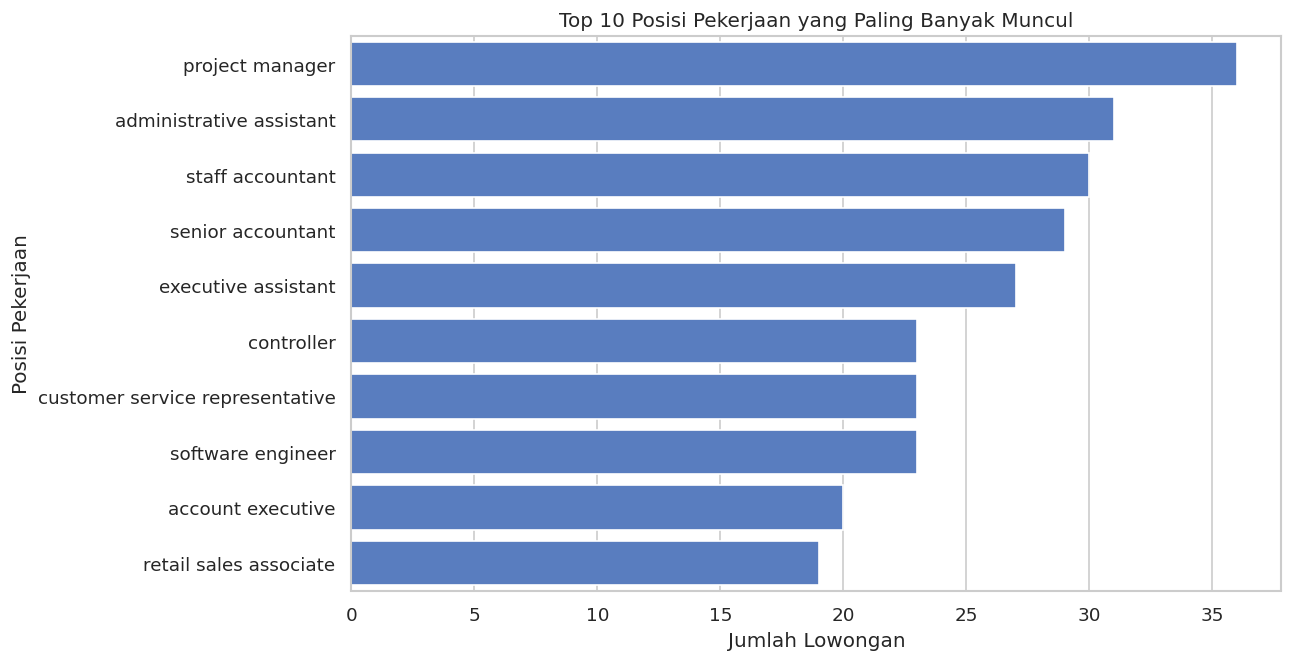

In [64]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=job_title_counts.head(10),
    x='Frequency',
    y='Job_Title'
)

plt.title('Top 10 Posisi Pekerjaan yang Paling Banyak Muncul')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Posisi Pekerjaan')

plt.show()

**Jawaban Pertanyaan Bisnis 2**

Berdasarkan hasil analisis, posisi pekerjaan yang paling banyak muncul dalam dataset adalah Project Manager (36 lowongan), diikuti oleh Administrative Assistant (31 lowongan), Staff Accountant (30 lowongan), dan Senior Accountant (29 lowongan).

Hasil ini menunjukkan bahwa dataset lowongan pekerjaan memiliki variasi posisi yang cukup beragam dan tidak didominasi oleh satu jenis pekerjaan tertentu. Posisi yang sering muncul berasal dari berbagai bidang, seperti manajemen proyek, administrasi, akuntansi, layanan pelanggan, dan teknologi informasi.

Kemunculan posisi seperti Project Manager dan Software Engineer menunjukkan adanya kebutuhan tenaga kerja pada bidang manajemen proyek dan teknologi. Sementara itu, tingginya jumlah lowongan Administrative Assistant dan Staff Accountant mengindikasikan bahwa fungsi administrasi dan keuangan juga memiliki peran penting dalam kebutuhan tenaga kerja pada dataset ini.

Temuan ini dapat digunakan sebagai referensi untuk menghubungkan kategori skill dengan peluang karier yang tersedia pada platform SkillMatch.

In [65]:
# ==============================================================================
# EDA 3 — Hubungan Kategori Skill dengan Posisi Pekerjaan
# ==============================================================================

job_skill = df_clean.copy()

# Pecah skill menjadi satu baris per skill
job_skill = (
    job_skill
    .assign(
        skill=job_skill['skill_abr'].str.split(',')
    )
    .explode('skill')
)

job_skill['skill'] = job_skill['skill'].str.strip()

# Mapping kode skill ke nama skill
job_skill['skill'] = job_skill['skill'].map(skill_mapping)

# Hitung frekuensi kombinasi Job Title dan Skill
job_skill_relation = (
    job_skill
    .groupby(['title_cleaned', 'skill'])
    .size()
    .reset_index(name='Frequency')
    .sort_values('Frequency', ascending=False)
)

job_skill_relation.head(20)

,title_cleaned,skill,Frequency
10106,project manager,Project Management,33
356,administrative assistant,Administration,31
13580,staff accountant,Accounting,30
10101,project manager,Information Technology,29
11834,senior accountant,Accounting,28
4710,executive assistant,Administration,27
11837,senior accountant,Finance,23
2922,controller,Accounting,23
13581,staff accountant,Finance,22
2925,controller,Finance,22


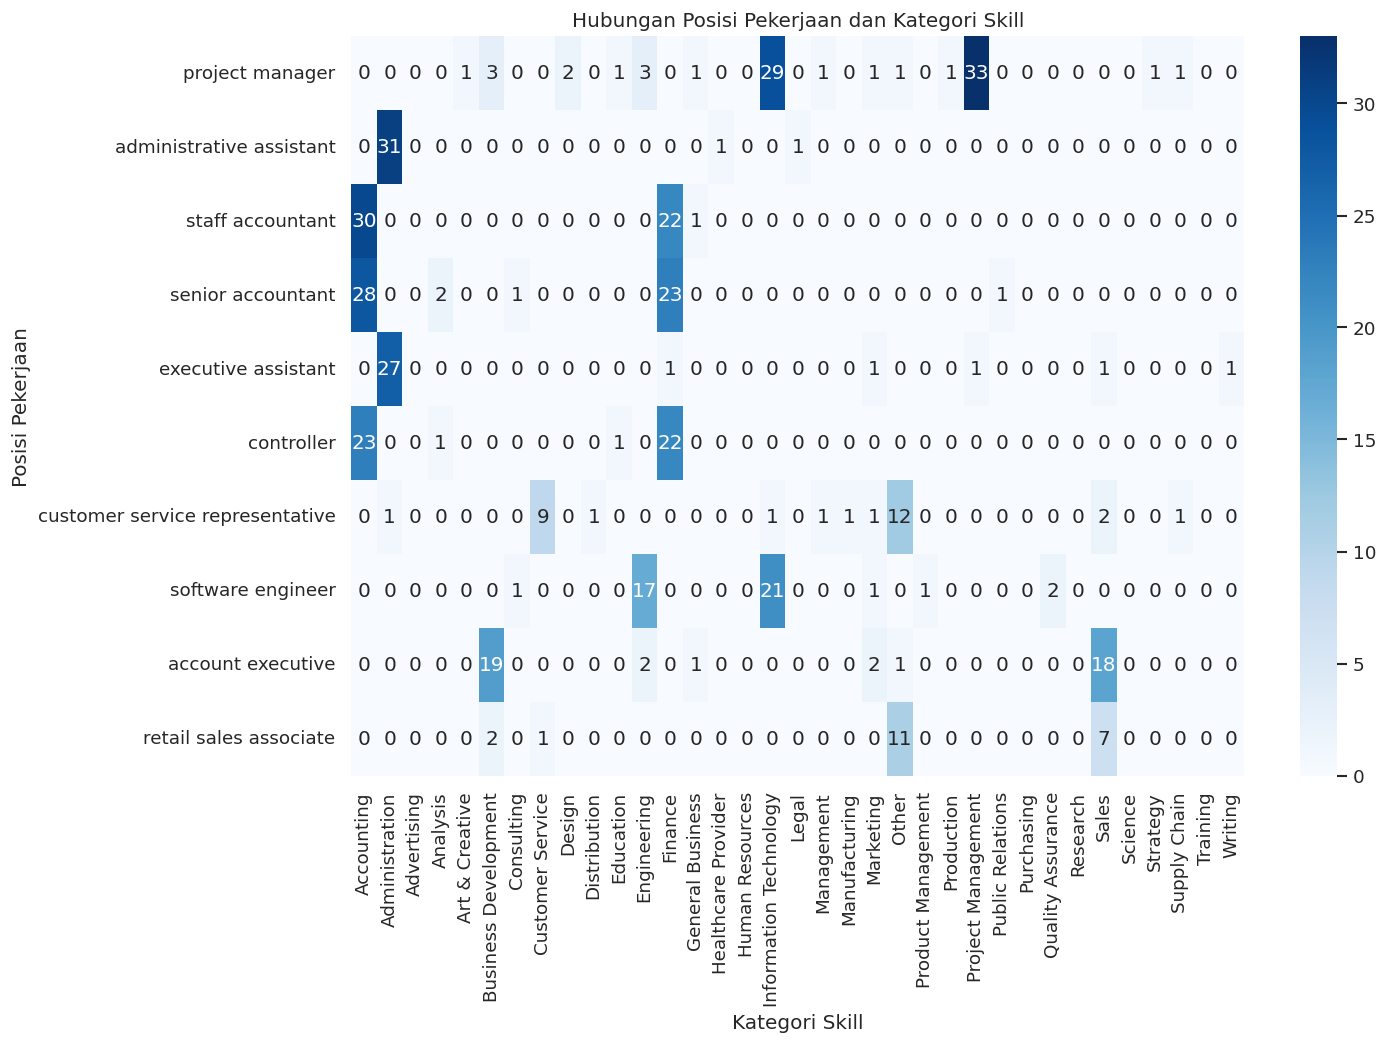

In [66]:
pivot_data = (
    job_skill_relation
    .pivot_table(
        index='title_cleaned',
        columns='skill',
        values='Frequency',
        fill_value=0
    )
)

top_jobs = (
    df_clean['title_cleaned']
    .value_counts()
    .head(10)
    .index
)

pivot_data = pivot_data.loc[top_jobs]

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_data,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title(
    'Hubungan Posisi Pekerjaan dan Kategori Skill'
)

plt.xlabel('Kategori Skill')
plt.ylabel('Posisi Pekerjaan')

plt.show()

**Jawaban Pertanyaan Bisnis 3**

Berdasarkan hasil analisis hubungan antara kategori skill dan posisi pekerjaan, ditemukan bahwa setiap posisi pekerjaan memiliki pola kompetensi yang berbeda.

Beberapa contoh hubungan yang terlihat dalam dataset antara lain:

Project Manager paling sering dikaitkan dengan kompetensi Project Management dan Information Technology. Software Engineer paling sering dikaitkan dengan kompetensi Information Technology dan Engineering. Staff Accountant dan Senior Accountant didominasi oleh kompetensi Accounting dan Finance. Sales Associate dan Salesperson paling sering dikaitkan dengan kompetensi Sales dan Business Development. Administrative Assistant dan Executive Assistant didominasi oleh kompetensi Administration.

Temuan ini menunjukkan bahwa kategori skill dapat digunakan sebagai indikator utama untuk mengidentifikasi pekerjaan yang sesuai dengan kemampuan pengguna.

Informasi hubungan antara kompetensi dan posisi pekerjaan ini menjadi dasar penting dalam pengembangan fitur Skill Gap Analysis, karena sistem dapat membandingkan kompetensi yang dimiliki pengguna dengan kompetensi yang umum dibutuhkan pada posisi pekerjaan target.

In [67]:
# ==============================================================================

# EDA 4. Berapa banyak kategori skill yang umumnya dibutuhkan dalam satu lowongan pekerjaan?

# ==============================================================================

avg_skills = df_clean['num_skills'].mean()

print(f"Rata-rata jumlah skill per lowongan: {avg_skills:.2f}")


Rata-rata jumlah skill per lowongan: 1.75


In [68]:
df_clean['num_skills'].value_counts().sort_index()

num_skills
1    4265
2    4905
3    1602
Name: count, dtype: int64

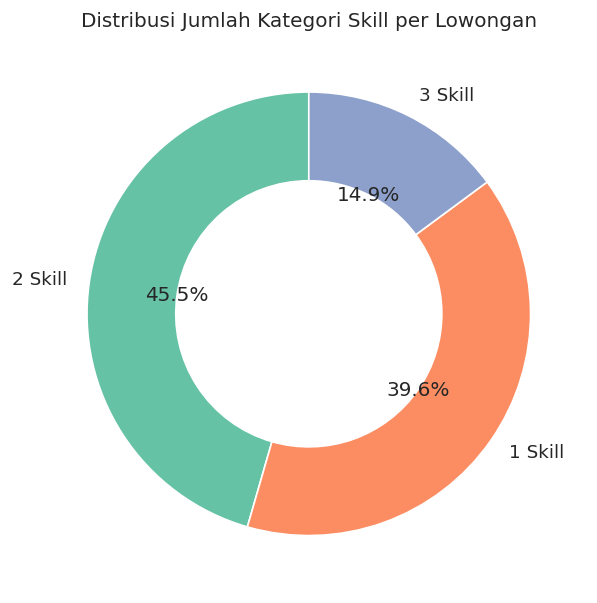

In [69]:
num_skills_counts = df_clean['num_skills'].value_counts()
labels = [f'{x} Skill' for x in num_skills_counts.index]

plt.figure(figsize=(6,6))
plt.pie(
    num_skills_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2'),
    wedgeprops=dict(width=0.4, edgecolor='w')
)

plt.title('Distribusi Jumlah Kategori Skill per Lowongan')
plt.show()


**Jawaban Pertanyaan Bisnis 4**

Berdasarkan hasil analisis, rata-rata jumlah kategori skill yang tercantum pada setiap lowongan adalah 1,75.

Distribusi menunjukkan bahwa mayoritas lowongan dalam dataset mencantumkan 2 kategori skill (4.905 lowongan), diikuti oleh 1 kategori skill (4.265 lowongan), sedangkan lowongan yang mencantumkan 3 kategori skill berjumlah 1.602.

Temuan ini menunjukkan bahwa sebagian besar lowongan pada dataset SkillMatch tidak dikaitkan dengan banyak kategori skill sekaligus, melainkan hanya satu hingga dua kategori utama yang merepresentasikan kebutuhan pekerjaan tersebut.

## Pemanfaatan Informasi Kategori Skill untuk Analisis Skill Gap

Hasil analisis menunjukkan bahwa setiap posisi pekerjaan memiliki kombinasi kategori skill yang berbeda. Sebagai contoh, posisi **Software Engineer** didominasi oleh kategori skill **Information Technology** dan **Engineering**, sedangkan posisi **Project Manager** didominasi oleh **Project Management** dan **Information Technology**. Pada bidang keuangan, posisi seperti **Staff Accountant** dan **Senior Accountant** umumnya membutuhkan kompetensi **Accounting** dan **Finance**.

Informasi mengenai hubungan antara posisi pekerjaan dan kategori skill tersebut dapat dimanfaatkan sebagai dasar pengembangan sistem **Skill Gap Analysis**. Sistem dapat membandingkan kompetensi yang dimiliki pengguna dengan kompetensi yang dibutuhkan oleh pekerjaan target yang dipilih.

Sebagai ilustrasi, apabila pengguna memilih target karier **Software Engineer** dan memiliki kompetensi **Information Technology**, maka sistem dapat mengidentifikasi bahwa pengguna masih memiliki kesenjangan kompetensi (*skill gap*) pada kategori **Engineering**. Berdasarkan hasil perbandingan tersebut, sistem dapat menghitung tingkat kecocokan kompetensi (*skill match score*) serta menampilkan kompetensi yang perlu dipelajari untuk meningkatkan peluang memperoleh pekerjaan yang diinginkan.

Selain itu, sistem juga dapat memberikan rekomendasi pekerjaan alternatif yang memiliki tingkat kesesuaian lebih tinggi dengan kompetensi pengguna saat ini. Dengan demikian, pengguna tidak hanya mengetahui kompetensi yang masih perlu dikembangkan, tetapi juga memperoleh gambaran peluang karier yang paling relevan berdasarkan kemampuan yang telah dimiliki.

Hasil analisis ini menunjukkan bahwa data kategori skill dan posisi pekerjaan dapat digunakan sebagai fondasi dalam membangun sistem rekomendasi karier berbasis **Skill Gap Analysis** yang membantu pengguna merencanakan pengembangan kompetensi secara lebih terarah.


## Ringkasan Insight

Berdasarkan hasil EDA diperoleh beberapa temuan utama:

1. Information Technology merupakan kategori skill dengan permintaan tertinggi dalam dataset.
2. Project Manager menjadi posisi pekerjaan yang paling sering muncul.
3. Setiap posisi pekerjaan memiliki kombinasi skill yang berbeda sehingga skill dapat digunakan sebagai indikator kecocokan pekerjaan.
4. Sebagian besar lowongan hanya membutuhkan satu hingga dua kategori skill utama.

## Kesimpulan

Berdasarkan hasil analisis terhadap 10.772 data lowongan pekerjaan, ditemukan bahwa kategori kompetensi yang paling banyak dibutuhkan adalah **Information Technology**, diikuti oleh **Management** dan **Sales**. Hasil ini menunjukkan bahwa kebutuhan tenaga kerja pada dataset didominasi oleh kompetensi di bidang teknologi, manajemen, dan bisnis.

Dari sisi posisi pekerjaan, beberapa jabatan yang paling sering muncul adalah **Project Manager**, **Administrative Assistant**, **Staff Accountant**, dan **Software Engineer**. Temuan ini menunjukkan bahwa peluang kerja dalam dataset tersebar pada berbagai bidang profesi dan tidak hanya terfokus pada satu sektor tertentu.

Analisis hubungan antara kategori kompetensi dan posisi pekerjaan menunjukkan bahwa setiap pekerjaan memiliki kombinasi kompetensi yang berbeda. Sebagai contoh, posisi **Software Engineer** umumnya membutuhkan kompetensi **Information Technology** dan **Engineering**, sedangkan posisi **Project Manager** didominasi oleh **Project Management** dan **Information Technology**. Hubungan ini menjadi dasar penting dalam menentukan kompetensi yang diperlukan untuk suatu target karier.

Selain itu, analisis jumlah kategori kompetensi menunjukkan bahwa sebagian besar lowongan pekerjaan hanya membutuhkan satu hingga dua kategori kompetensi utama. Temuan ini mengindikasikan bahwa pengguna tidak harus menguasai seluruh kategori kompetensi yang tersedia, melainkan dapat berfokus pada kompetensi inti yang sesuai dengan target karier yang dipilih.

Secara keseluruhan, hasil analisis ini menunjukkan bahwa data kategori kompetensi dan posisi pekerjaan dapat dimanfaatkan sebagai fondasi pengembangan aplikasi **SkillMatch**. Melalui pendekatan **Skill Match** dan **Skill Gap Analysis**, sistem dapat membantu pengguna mengukur tingkat kecocokan kompetensi terhadap pekerjaan yang dituju, mengidentifikasi kompetensi yang masih perlu dipelajari, serta memberikan rekomendasi pekerjaan yang sesuai dengan kompetensi yang dimiliki.
